# Middle-Class Neighborhood Identification

This notebook identifies "middle-class" zipcodes in the King County housing dataset by ranking zipcodes on **average house price** and taking the middle tercile (33rd–67th percentile). It then checks whether the resulting price differences between tiers are driven by house size, or represent a genuine location premium.

**Input:** `housing_cleaned.pkl` (cleaned dataset from `01_cleanfinal.ipynb`)

Imports used throughout: `pandas`/`numpy` for data handling, `matplotlib` for plotting, and `matplotlib.ticker` for formatting axis labels.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Load the cleaned dataset

Read the pickled DataFrame produced by the cleaning notebook and do a quick sanity check (`.head()` for a preview, `.info()` for column types and non-null counts).

In [15]:
df = pd.read_pickle("../data/housing_cleaned.pkl")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   bedrooms       21597 non-null  float64       
 2   bathrooms      21597 non-null  float64       
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  float64       
 6   waterfront     21597 non-null  int64         
 7   view           21597 non-null  int64         
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21597 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   21597 non-null  int64         
 14  zipcode        21597 non-null  int64         
 15  lat            21597 non-null 

In [19]:
df["price"].max()

np.float64(7700000.0)

## Average price by zipcode

Group all sales by `zipcode` and take the mean `price` in each group, sorted ascending. This gives one average price per zipcode (70 zipcodes total) — the basis for ranking neighborhoods from cheapest to most expensive.

In [7]:
avg_price_by_zip = df.groupby("zipcode")["price"].mean().sort_values()
avg_price_by_zip.info()

<class 'pandas.Series'>
Index: 70 entries, 98002 to 98039
Series name: price
Non-Null Count  Dtype  
--------------  -----  
70 non-null     float64
dtypes: float64(1)
memory usage: 1.1 KB


## Visualize average price by zipcode

A horizontal bar chart of the sorted `avg_price_by_zip` series, so the relative price ranking across all 70 zipcodes can be seen at a glance.

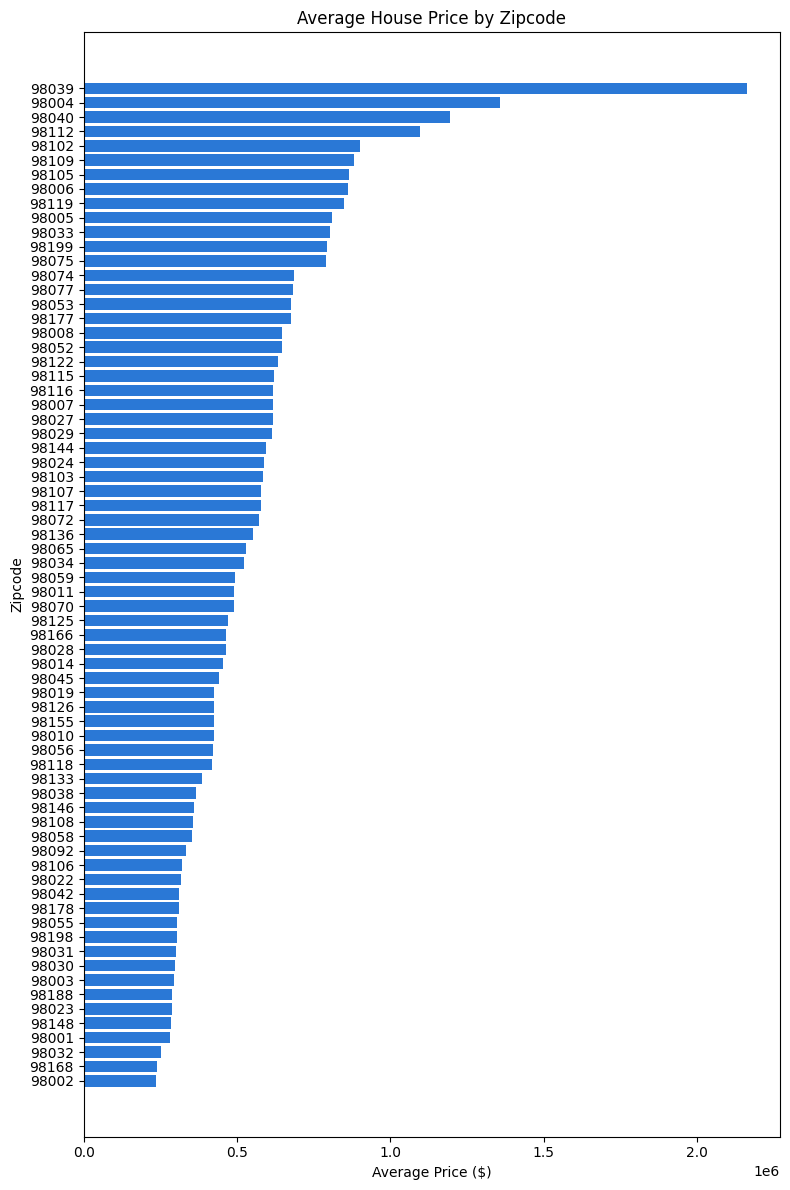

In [8]:
fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(avg_price_by_zip.index.astype(str), avg_price_by_zip.values, color="#2a78d6")
ax.set_xlabel("Average Price ($)")
ax.set_ylabel("Zipcode")
ax.set_title("Average House Price by Zipcode")
plt.tight_layout()
plt.show()


## Define "middle-class" zipcodes

Use the 33rd and 67th percentiles of `avg_price_by_zip` as cutoffs, then keep only the zipcodes whose average price falls between them (inclusive). This is the tercile method used to define "middle-class" neighborhoods for this analysis — roughly the middle third of zipcodes by average price, not any external income/demographic data.

In [9]:
lower_cutoff = avg_price_by_zip.quantile(0.33)
upper_cutoff = avg_price_by_zip.quantile(0.67)

middle_class_zips = avg_price_by_zip[(avg_price_by_zip >= lower_cutoff) & (avg_price_by_zip <= upper_cutoff)]
print(middle_class_zips)

zipcode
98056    420895.475369
98010    423665.990000
98155    423736.905830
98126    424734.604520
98019    424815.063158
98045    440232.313636
98014    455617.112903
98028    462488.869258
98166    464322.389764
98125    469928.767726
98070    489382.017094
98011    490377.107692
98059    493625.309829
98034    521740.014679
98065    529629.782468
98136    551768.520913
98072    570073.520147
98117    576834.808318
98107    579109.808271
98103    585048.779070
98024    586120.875000
98144    594706.542274
98029    612642.738318
98027    617053.966019
Name: price, dtype: float64


## Filter the full dataset to middle-class zipcodes

`middle_class_zip_list` is the list of zipcodes that passed the tercile filter above. `df_middle_class_zip` is the subset of house sales located in those zipcodes, with the index reset after filtering.

In [10]:
middle_class_zip_list = middle_class_zips.index.tolist()
df_middle_class_zip = df[df["zipcode"].isin(middle_class_zip_list)].reset_index(drop=True)
df_middle_class_zip.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,400.0,1951,1991,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
1,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,0.0,1933,0,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
2,2487200875,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,...,910.0,1965,0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
3,114101516,3.0,1.00,1430.0,19901.0,1.5,0,0,4,7,...,0.0,1927,0,98028,47.7558,-122.229,1780.0,12697.0,2014-05-28,310000.0
4,1175000570,5.0,2.00,1810.0,4850.0,1.5,0,0,3,7,...,0.0,1900,0,98107,47.6700,-122.394,1360.0,4850.0,2015-03-12,530000.0


## Tag every house with a price tier, and compute price per sqft

`tier_from_avg_price` labels a zipcode's average price as `'bottom'`, `'middle'`, or `'top'` relative to the same cutoffs used above. Mapping this back onto `df['zipcode']` adds a `zip_tier` column to every house, not just the middle-class subset.

`price_per_sqft` (`price / sqft_living`) normalizes price for house size, so the tiers can be compared without size differences skewing the comparison.

`tier_summary` aggregates by tier to check: is the price/sqft difference between tiers just because houses are bigger in expensive areas, or is location itself commanding a premium?

In [11]:
def tier_from_avg_price(avg_price):
    if avg_price < lower_cutoff:
        return 'bottom'
    elif avg_price <= upper_cutoff:
        return 'middle'
    else:
        return 'top'

zip_tier_map = avg_price_by_zip.apply(tier_from_avg_price)
df['zip_tier'] = df['zipcode'].map(zip_tier_map)

df['price_per_sqft'] = df['price'] / df['sqft_living']

tier_summary = df.groupby('zip_tier').agg(
    avg_sqft=('sqft_living', 'mean'),
    avg_price_per_sqft=('price_per_sqft', 'mean'),
    n=('price', 'count')
)
print(tier_summary)


             avg_sqft  avg_price_per_sqft     n
zip_tier                                       
bottom    1842.798731          185.903600  7249
middle    2000.875996          273.112621  7532
top       2420.725499          337.442029  6816


## Compare price across tiers at matched house sizes

A grouped bar chart of average `price` by house-size bucket (`sqft_bucket`, created via `pd.cut` on `sqft_living`), split by `zip_tier`, to check whether the tier price gap holds even among similarly-sized homes (controlling for size directly, rather than relying on the tier average alone).

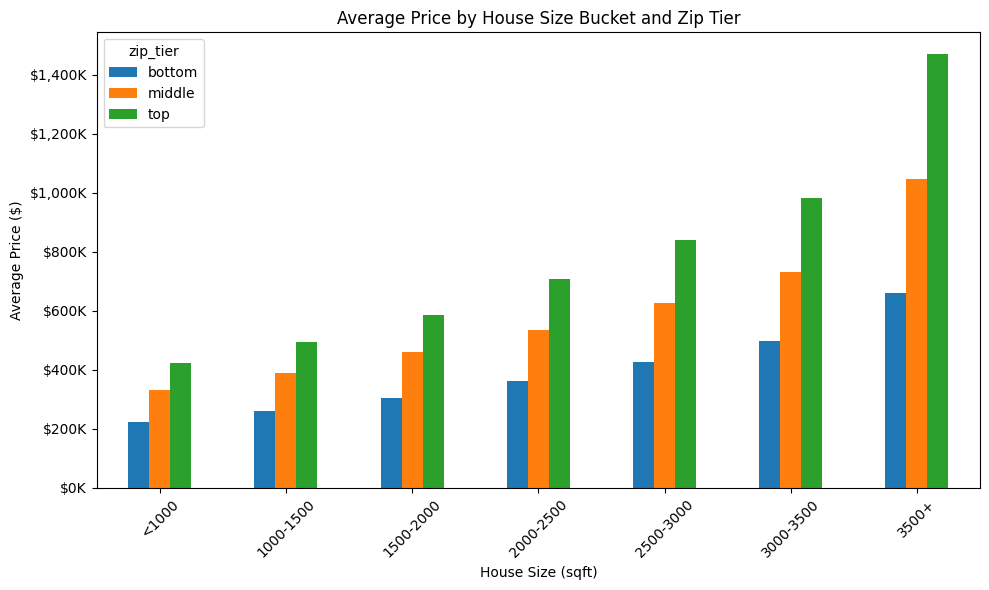

In [13]:
sqft_bins = [0, 1000, 1500, 2000, 2500, 3000, 3500, np.inf]
sqft_labels = ['<1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-3500', '3500+']
df['sqft_bucket'] = pd.cut(df['sqft_living'], bins=sqft_bins, labels=sqft_labels)

bucket_tier_price = df.groupby(['sqft_bucket', 'zip_tier'])['price'].mean().unstack('zip_tier')
bucket_tier_price = bucket_tier_price[['bottom', 'middle', 'top']]

ax = bucket_tier_price.plot(kind='bar', figsize=(10, 6))
ax.set_xlabel('House Size (sqft)')
ax.set_ylabel('Average Price ($)')
ax.set_title('Average Price by House Size Bucket and Zip Tier')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Location Premium in House Prices

**Hypothesis:** House prices differ significantly by location (zipcode), and this difference holds independent of house size or features — meaning there is a location premium baked into prices, which can be used to identify middle-class neighborhoods.

**Method:**
Zipcodes were split into three tiers (bottom/middle/top) based on their average house price, using the 33rd and 67th percentile cutoffs across all zipcode averages. This tiering was then applied at the house level to compare outcomes across groups.

**Findings:**

1. **Size vs. price/sqft by tier** — average house size was comparable across tiers (bottom: 1843 sqft, middle: 2000 sqft, top: 2420 sqft), while average price per square foot differed clearly (bottom: $185/sqft, middle: $273/sqft, top: $337/sqft). Because size stayed roughly flat while price/sqft moved, the price gap between tiers isn't explained by houses simply being bigger or smaller — it's a per-square-foot premium tied to the zipcode itself.

2. **Same-size comparison** — bucketing houses by sqft range and comparing price across tiers within each bucket showed a consistent bottom < middle < top ordering at every single bucket, from the smallest homes (<1000 sqft: ~$224K bottom vs. ~$331K middle vs. ~$424K top) up through the largest (3500+ sqft: ~$662K bottom vs. ~$1.05M middle vs. ~$1.47M top). The dollar gap between tiers widens as house size increases, but the tier ordering never reverses or collapses at any bucket. This directly controls for size and shows the tier-based price difference persists even when comparing similarly-sized homes.

**Conclusion:**
Both analyses support the hypothesis: location (zipcode) carries a price premium that isn't simply a proxy for house size. This validates the tercile-based method (33rd–67th percentile of average zipcode price) as a reasonable way to identify "middle-class" neighborhoods for this dataset — the middle-tier zipcodes are meaningfully distinct from the bottom and top tiers on a size-adjusted basis, not just on raw average price.